In [1]:
#twitter sentiment analysis using LSTM

In [2]:
#importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

import re

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

In [3]:
#importing the dataset

df = pd.read_csv("C:\\Users\\bhavi\\OneDrive\\Documents\\twitter_training.csv")

df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [4]:
#naming the columns

df.columns = ["Index", "Company", "Sentiment", "Tweet"]

df

,Index,Company,Sentiment,Tweet
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
...,...,...,...,...
74676,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74677,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74678,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74679,9200,Nvidia,Positive,Just realized between the windows partition of...


In [5]:
#-------------cleaning the dataset-------------

In [6]:
#removing the unnecessary columns

df.drop(["Index","Company"], axis=1, inplace=True)

df

,Sentiment,Tweet
0,Positive,I am coming to the borders and I will kill you...
1,Positive,im getting on borderlands and i will kill you ...
2,Positive,im coming on borderlands and i will murder you...
3,Positive,im getting on borderlands 2 and i will murder ...
4,Positive,im getting into borderlands and i can murder y...
...,...,...
74676,Positive,Just realized that the Windows partition of my...
74677,Positive,Just realized that my Mac window partition is ...
74678,Positive,Just realized the windows partition of my Mac ...
74679,Positive,Just realized between the windows partition of...


In [7]:
#number of rows and columns

df.shape

(74681, 2)

In [8]:
#number of null values in each and every column

df.isnull().sum()

Sentiment      0
Tweet        686
dtype: int64

In [9]:
#removing the rows that have the null value

df.dropna(inplace=True)

df.isnull().sum()

Sentiment    0
Tweet        0
dtype: int64

In [10]:
#dropping the duplicate values

df.drop_duplicates(subset=["Tweet"], inplace=True)

In [11]:
df.shape

(69490, 2)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69490 entries, 0 to 74680
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentiment  69490 non-null  object
 1   Tweet      69490 non-null  object
dtypes: object(2)
memory usage: 1.6+ MB


In [13]:
#working with stopwords and porterstemmer and re

stop_words = set(stopwords.words("english"))
stop_words.discard("not")
stop_words.discard("no")
stop_words.discard("never")
stop_words.discard("but")

ps = PorterStemmer()

def clean_text(text):
    filtered_words = []
    stemmed_words = []

    text = re.sub("[^a-zA-Z]", " ", text)
    text = text.lower().split()  #this needs to be initialised back

    for word in text:
        if word not in stop_words:
            filtered_words.append(word)

    for word in filtered_words:
        stemmed_words.append(ps.stem(word))

    return " ".join(stemmed_words)

df["Tweet"] = df["Tweet"].apply(clean_text)

In [14]:
#Positive=0, Negative=1, Neutral=2, Irrelevant=3

lb = LabelEncoder()
lb.classes_ = np.array(['Positive', 'Negative', 'Neutral', 'Irrelevant'])

# now manually map instead of fit_transform
sentiment_mapping = {label: idx for idx, label in enumerate(lb.classes_)}
print("New mapping:", sentiment_mapping)

df["Sentiment"] = df["Sentiment"].map(sentiment_mapping)

New mapping: {np.str_('Positive'): 0, np.str_('Negative'): 1, np.str_('Neutral'): 2, np.str_('Irrelevant'): 3}


In [15]:
#mapping of the encoding

for i, label in enumerate(lb.classes_):
    print(i, "->", label)

0 -> Positive
1 -> Negative
2 -> Neutral
3 -> Irrelevant


In [16]:
x = df["Tweet"]
y = df["Sentiment"]

In [17]:
#tokenizer

x = [str(i) for i in x]

tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(x)

sequences = tokenizer.texts_to_sequences(x)

In [18]:
#padding

max_len = 100

x_padded = pad_sequences(sequences, maxlen=max_len, padding="post", truncating="post")

#padding="post" means add zeros at the end of the tweet to keep the tweet of the same length
#if padding="pre" -- means zeros will be added at the starting of the tweet
#truncating="post" means -- suppose if the tweet is of more than 100 words, then it will be cut from the end to keep the length same
#same theory goes for truncating="pre"

In [19]:
#splitting the model into training and testing parts

x_train, x_test, y_train, y_test = train_test_split(x_padded, y, test_size=0.2, random_state=42)

In [20]:
#early stopping

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

In [21]:
#added ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)

#learning rate controls how big the steps should be taken to make the model learn the things
#high LR -- big steps and vice versa

#Plateau means -- a plateau is when the model stops learning -- it means when the model feels stuck
#It watches the loss every epoch, and when it sees the model is stuck/not improving, it automatically reduces the learning rate to help the model take smaller, more careful steps to escape the plateau.

#factor=0.5 means that cut the learning rate in half when the model feels stuck
#min_lr -- never go beyond this learning rate

In [22]:
model = Sequential([
    Embedding(10000, 128, input_length=max_len),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(64, activation="relu", kernel_regularizer=l2(0.01)),
    Dropout(0.4),  #dropout before final layer -- prevents overfitting
    Dense(4, activation='softmax')
    ])

#the first LSTM learns the basic patterns (word order, short phrases) and the second LSTM learns high level patterns like sarcasm, negation, complex statements
#bidirectional reads the text from both left to right and right to left
#return_sequences=True means that it returns the whole sentence to the next LSTM layer

#SpatialDropout1D -- better than normal dropout for embedding -- it drops the entire word vectors instead of random individual vectors -- this forces the model not to rely on just one single word too heavily
#embedding layer -- converts word indices into dense vectors

#Dropout prevents overfitting — when the model memorizes training data instead of actually learning patterns.
#It works by randomly switching off some neurons during training, forcing the model to not rely on any single neuron too heavily.

#spatialdropout1d -- This forces the model to not rely on any single word for sentiment — which is exactly what we want! The model should understand the full sentence, not just key words.

#recurrent_dropout -- drops some of the lstm memory parts between layers

# L2 penalizes the model for having large weights — forces it to stay simple

C:\Users\bhavi\PycharmProjects\PythonProject\.venv310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


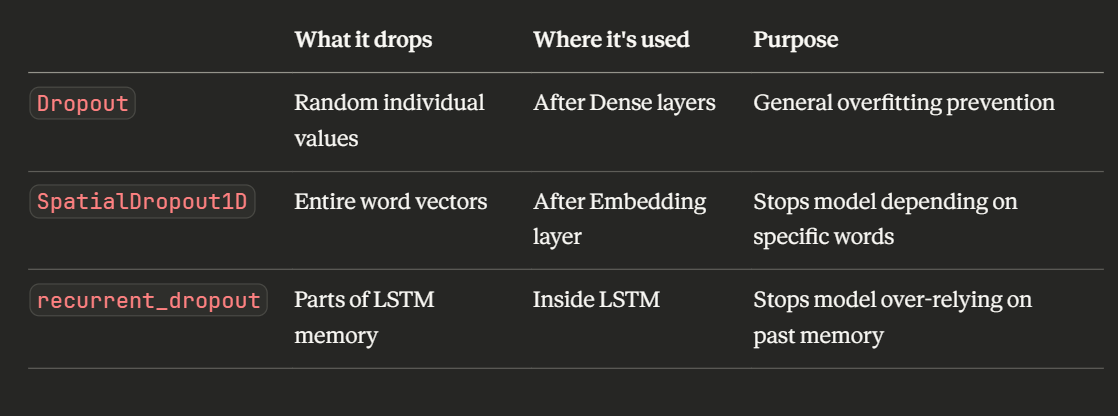

In [23]:
#telling the model how to learn the stuff

optimizer = Adam(learning_rate=0.001)

model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [24]:
#fitting the architecture to the model

history = model.fit(x_train, y_train, batch_size=64, epochs=15, validation_split=0.2, callbacks=[early_stop, reduce_lr])

Epoch 1/15
695/695 ━━━━━━━━━━━━━━━━━━━━ 583s 797ms/step - accuracy: 0.5310 - loss: 1.1814 - val_accuracy: 0.6637 - val_loss: 0.8809 - learning_rate: 0.0010
Epoch 2/15
695/695 ━━━━━━━━━━━━━━━━━━━━ 635s 913ms/step - accuracy: 0.7307 - loss: 0.7534 - val_accuracy: 0.7508 - val_loss: 0.6951 - learning_rate: 0.0010
Epoch 3/15
695/695 ━━━━━━━━━━━━━━━━━━━━ 620s 892ms/step - accuracy: 0.8050 - loss: 0.5711 - val_accuracy: 0.7869 - val_loss: 0.5895 - learning_rate: 0.0010
Epoch 4/15
695/695 ━━━━━━━━━━━━━━━━━━━━ 625s 899ms/step - accuracy: 0.8400 - loss: 0.4773 - val_accuracy: 0.8108 - val_loss: 0.5482 - learning_rate: 0.0010
Epoch 5/15
695/695 ━━━━━━━━━━━━━━━━━━━━ 631s 907ms/step - accuracy: 0.8602 - loss: 0.4148 - val_accuracy: 0.8220 - val_loss: 0.5182 - learning_rate: 0.0010
Epoch 6/15
695/695 ━━━━━━━━━━━━━━━━━━━━ 619s 891ms/step - accuracy: 0.8726 - loss: 0.3776 - val_accuracy: 0.8323 - val_loss: 0.5069 - learning_rate: 0.0010
Epoch 7/15
695/695 ━━━━━━━━━━━━━━━━━━━━ 802s 1s/step - accuracy:

In [25]:
#displaying the training accuracy and validation accuracy

print("Training accuracy per epoch: ", history.history["accuracy"])
print("Validation accuracy per epoch: ", history.history["val_accuracy"])

Training accuracy per epoch:  [0.5310187935829163, 0.7307354807853699, 0.8049827814102173, 0.8399702906608582, 0.8602073192596436, 0.8725743889808655, 0.8839070796966553, 0.8939806222915649, 0.9027724862098694, 0.9074719548225403, 0.9142850637435913, 0.9168934226036072, 0.9297776222229004, 0.9356688261032104, 0.9386819005012512]
Validation accuracy per epoch:  [0.6637287735939026, 0.7507869601249695, 0.7869412899017334, 0.8107743263244629, 0.8220163583755493, 0.8322690725326538, 0.8370357155799866, 0.8371256589889526, 0.8416224718093872, 0.8486374616622925, 0.8514254689216614, 0.8536738753318787, 0.8598794937133789, 0.8633869886398315, 0.8654555082321167]


In [26]:
#making the model do predictions

y_pred = model.predict(x_test)

y_pred

435/435 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step


array([[8.02081486e-05, 5.44895083e-05, 9.99649763e-01, 2.15522319e-04],
       [1.28136249e-02, 9.64052141e-01, 6.99037313e-03, 1.61438640e-02],
       [2.80641514e-04, 6.17493861e-05, 1.96153444e-04, 9.99461472e-01],
       ...,
       [3.14588397e-05, 1.91733998e-05, 9.99840140e-01, 1.09245630e-04],
       [2.26802571e-04, 9.99217510e-01, 4.29399370e-04, 1.26213941e-04],
       [1.33091835e-02, 1.08860722e-02, 9.63670135e-01, 1.21346228e-02]],
      shape=(13898, 4), dtype=float32)

In [27]:
y_pred_classes = np.argmax(y_pred, axis=1)

y_pred_classes

array([2, 1, 3, ..., 2, 1, 2], shape=(13898,))

In [28]:
#printing the accuracy

accuracy = accuracy_score(y_test, y_pred_classes)

print("The accuracy score is: ", accuracy)

The accuracy score is:  0.8624262483810621


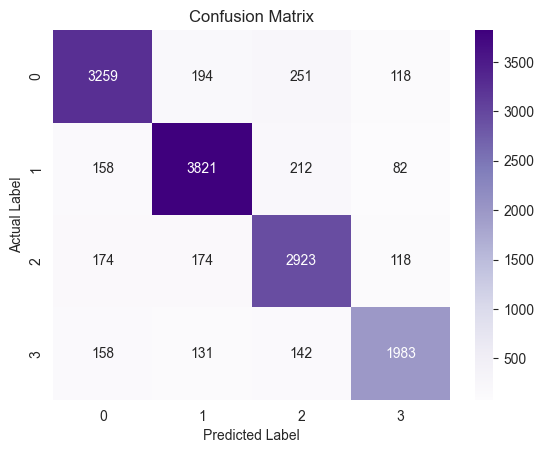

In [29]:
#confusion matrix

cm = confusion_matrix(y_test, y_pred_classes)

sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

In [30]:
import pickle

# Save the LSTM model
model.save("sentiment_model.h5")

# Save the tokenizer (VERY important — app needs this too!)
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# Save the label encoder
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(lb, f)

print("✅ Model and tokenizer saved successfully!")

✅ Model and tokenizer saved successfully!


In [14]:
df["Sentiment"].value_counts()

Sentiment
Negative      21166
Positive      19066
Neutral       17042
Irrelevant    12216
Name: count, dtype: int64

In [15]:
# Check class distribution BEFORE balancing
print("Sentiment Distribution:")
print(df["Sentiment"].value_counts())
print("\nIn percentages:")
print(df["Sentiment"].value_counts(normalize=True) * 100)

Sentiment Distribution:
Sentiment
Negative      21166
Positive      19066
Neutral       17042
Irrelevant    12216
Name: count, dtype: int64

In percentages:
Sentiment
Negative      30.459059
Positive      27.437041
Neutral       24.524392
Irrelevant    17.579508
Name: proportion, dtype: float64
